In [1]:
import colorsys
import numpy as np
import matplotlib
import matplotlib.pylab as plt
import scipy
import seaborn as sns
import time

In [2]:
import os
import sys
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))

In [5]:
from src.policy_analysis import plot_policy, plot_arrows, plot_env, plot_visit_table_heatmap, plot_visit_table_counts, plot_reward_table_heatmap

[ 3  4  4  5  7 12 13 13 14 17 21 22 22 23 30 31 31 32 39 40 40 41 48 49
 49 50 57 58 58 59 66 67 68 76]


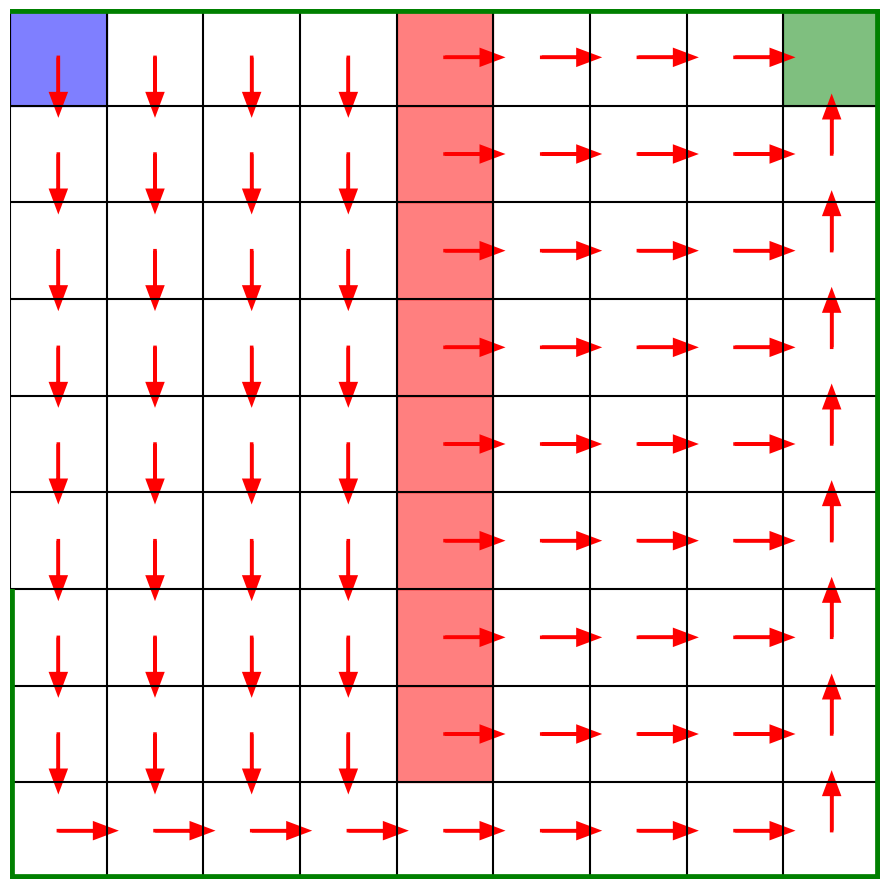

In [17]:
env_random = 0.1
n_steps = "5k"
seed = 12
eps = 1.0
q_lr = 0.1
r_lr = 0.1

log_dir = "../models_{}/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(n_steps, env_random, eps, q_lr, r_lr)
perfect_r_model = np.load("../models/9_9/Penalty/reward_model/perfect_reward_table.npy")
reward_table = np.load(log_dir + "/reward_model_table_{}.npy".format(seed))
print(np.nonzero(perfect_r_model - reward_table)[0])
fig = plot_policy(log_dir, "TreasureHunt-Penalty-v1", ["reward_model"], seed=seed, save_fig=False)
# q_table = np.load(log_dir + "/critic_q_table_{}.npy".format(seed))
# print("pos q-values ", len(np.where(q_table > 0)[0]))

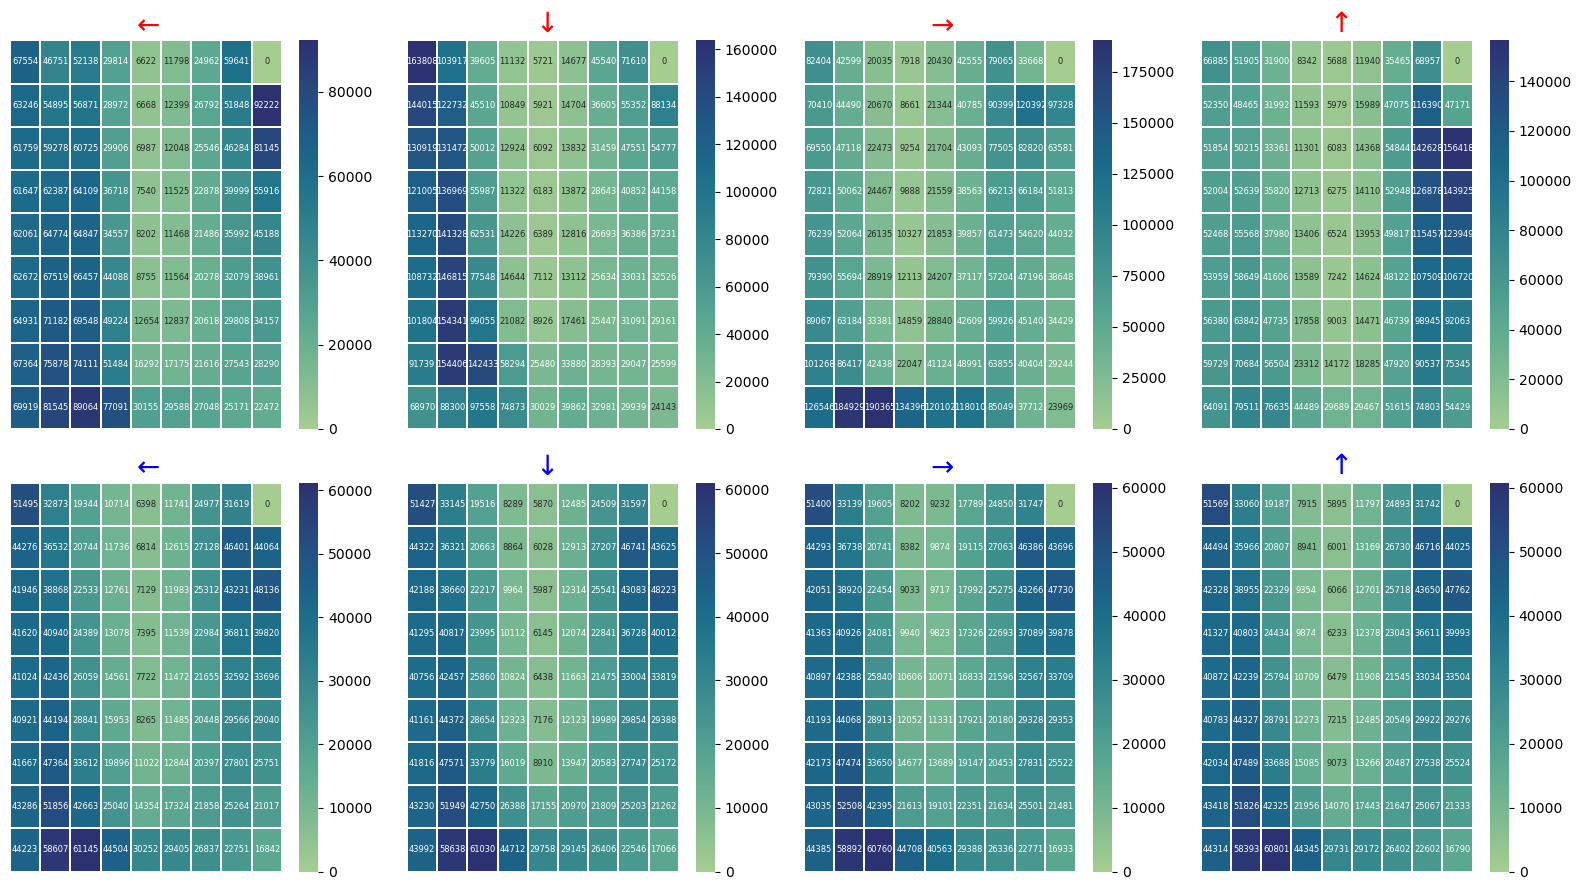

In [12]:
plot_visit_table_heatmap(log_dir, seed=seed, save_fig=False)

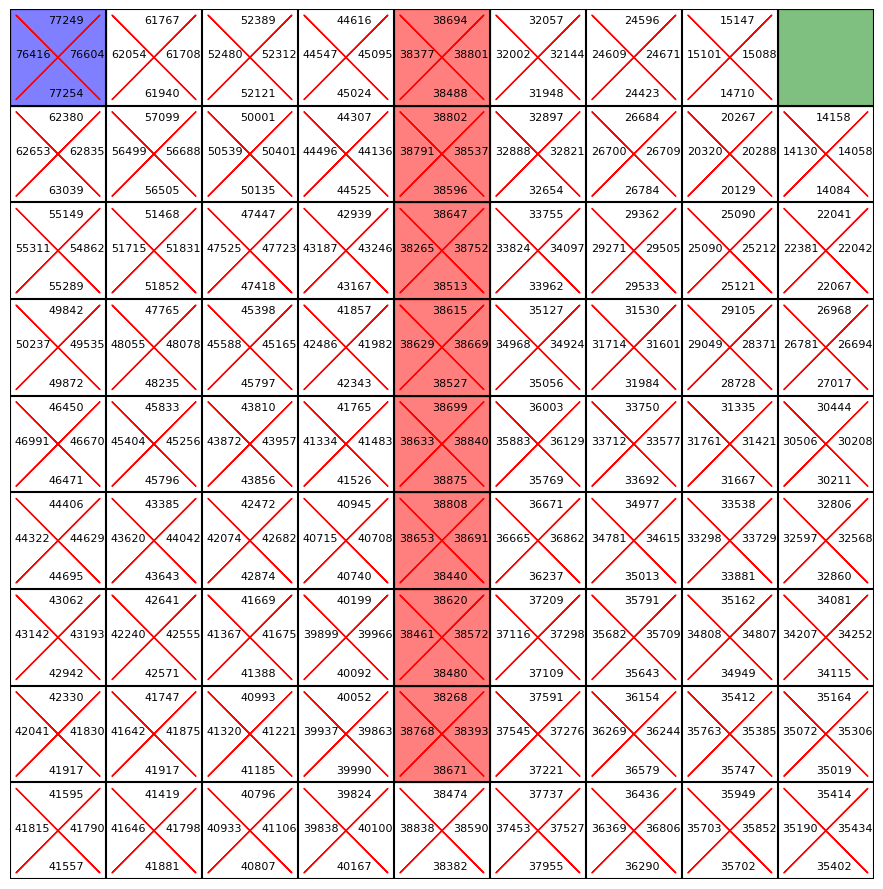

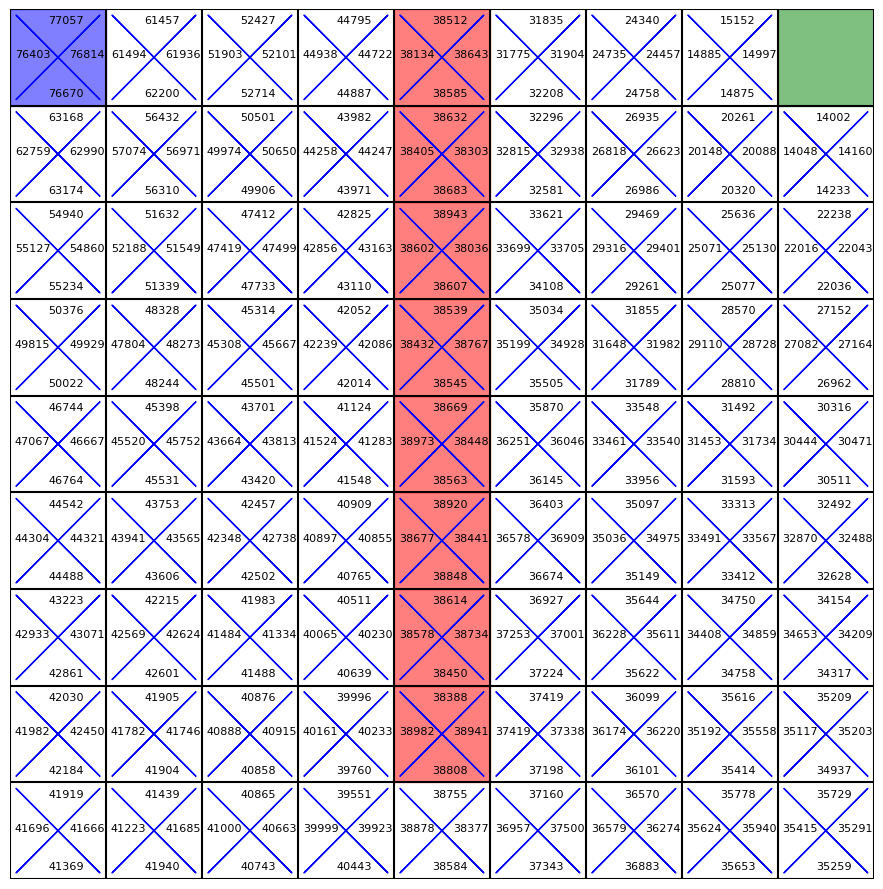

In [22]:
plot_visit_table_counts(log_dir, seed=seed, save_fig=False)

In [4]:
ARROWS = {0: (-1.5, 0), 1: (0, -1.5), 2: (1.5, 0), 3: (0, 1.5)}
JOINT_STATES = [
    "(0,0)",
    "(1,0)",
    "(2,0)",
    "(3,0)",
    "(4,0)",
    "(5,0)",
    "(6,0)",
    "(7,0)",
    "(8,0)",
    "(0,1)",
    "(1,1)",
    "(2,1)",
    "(3,1)",
    "(4,1)",
    "(5,1)",
    "(6,1)",
    "(7,1)",
    "(8,1)",
]
MDP_ACTIONS = [r"$\leftarrow$", r"$\downarrow$", r"$\rightarrow$", r"$\uparrow$"]
JOINT_ACTIONS = [
    r"($\leftarrow$,0)",
    r"($\downarrow$,0)",
    r"($\rightarrow$,0)",
    r"($\uparrow$,0)",
    r"($\leftarrow$,1)",
    r"($\downarrow$,1)",
    r"($\rightarrow$,1)",
    r"($\uparrow$,1)",
]

In [5]:
def plot_q_table_heatmap(log_dir: str, grid_size: tuple = (3, 3), seed: int = 1, save_fig: bool = False) -> None:
    """Plot Monitor Q-Table for values as a heatmap"""
    q_table = np.load(log_dir + "/critic_q_table_{}.npy".format(seed))
    n_states = int(grid_size[0] * grid_size[1])
    y_sticks = JOINT_STATES if q_table.shape[0] == 2 * n_states else np.arange(q_table.shape[0])

    fig = plt.figure(figsize=(7 if n_states == 9 else 20, 8 if len(y_sticks) == 18 else 12))
    axis = sns.heatmap(
        q_table,
        cmap="crest",
        annot=True,
        linewidth=0.01,
        fmt=".2f",
        annot_kws={"fontsize": 12 if n_states == 9 else 9},
    )
    axis.set_xlabel("Actions", fontsize=15)
    axis.set_ylabel("States", fontsize=15)
    axis.set_xticklabels(MDP_ACTIONS if q_table.shape[1] == 4 else JOINT_ACTIONS, fontsize=13)
    axis.set_yticks(0.5 + np.arange(len(y_sticks)))
    axis.set_yticklabels(y_sticks, fontsize=10 if len(y_sticks) == 18 else 7)
    plt.tight_layout()
    if save_fig:
        fig.savefig(log_dir + "/q_table_heatmap_{}.pdf".format(seed), dpi=300)

In [ ]:
env_random = 0.2
seed = 0
eps = 0.05
q_lr = 0.1
r_lr = 0.1
log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
plot_q_table_heatmap(log_dir, seed=seed, grid_size=(9, 9), save_fig=False)

In [7]:
def plot_reward_table_heatmap(log_dir: str, grid_size: tuple = (3,3), seed: int = 1, save_fig: bool = False) -> None:
    """Plot Predictive reward table values as a heatmap"""
    n_states = int(grid_size[0] * grid_size[1])
    fig = plt.figure(figsize=(7 if n_states == 9 else 15, 10))
    r_table = np.load(log_dir + "/reward_model_table_{}.npy".format(seed))
    ax_r = sns.heatmap(
        r_table,
        cmap="crest",
        annot=True,
        linewidth=0.1,
        fmt=".4f",
        annot_kws={"fontsize": 12 if n_states == 9 else 9},
    )
    ax_r.set_xlabel("Actions", fontsize=15)
    ax_r.set_ylabel("States", fontsize=15)
    ax_r.set_xticklabels(MDP_ACTIONS, fontsize=15)
    fig.tight_layout()
    if save_fig:
        fig.savefig(log_dir + "/predictive_reward_table_heatmap_{}.pdf".format(seed), dpi=300)

In [12]:
env_random = 0.1
seed = 10
eps = 0.1
q_lr = 0.1
r_lr = 0.1
log_dir = "../../mon_mdp_old/models_500/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
plot_reward_table_heatmap(log_dir, seed=seed, grid_size=(9, 9), save_fig=False)

FileNotFoundError: [Errno 2] No such file or directory: '../../mon_mdp_old/models_500/9_9/Penalty/reward_model/env_0.1/eps_0.1/q_lr_0.1/reward_lr_0.1/reward_model_table_10.npy'

<Figure size 1500x1000 with 0 Axes>

In [87]:
for env_random in [0.1, 0.2]:
    for eps in [0.05, 0.1]:
        for q_lr in [1.0, 0.5, 0.1]:
            for r_lr in [1.0, 0.5, 0.1]:
                log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
                count = 0
                for seed in range(30):
                    r_table = np.load(log_dir + "/reward_model_table_{}.npy".format(seed))
                    if np.max(r_table) >0:
                        count += 1
                        # print(np.where(np.load(log_dir + "/reward_model_table_{}.npy".format(seed)) > 0))
                        # print(seed)
                if count > 0:
                    print("\nenv_random = {}, eps = {}, q_lr= {}, r_lr = {} \t # seeds= {} / 30".format(env_random, eps, q_lr, r_lr, count))


env_random = 0.1, eps = 0.05, q_lr= 1.0, r_lr = 1.0 	 # seeds= 3 / 30

env_random = 0.1, eps = 0.05, q_lr= 1.0, r_lr = 0.5 	 # seeds= 1 / 30

env_random = 0.1, eps = 0.1, q_lr= 1.0, r_lr = 1.0 	 # seeds= 6 / 30

env_random = 0.1, eps = 0.1, q_lr= 1.0, r_lr = 0.5 	 # seeds= 3 / 30

env_random = 0.1, eps = 0.1, q_lr= 1.0, r_lr = 0.1 	 # seeds= 2 / 30

env_random = 0.2, eps = 0.05, q_lr= 1.0, r_lr = 1.0 	 # seeds= 2 / 30

env_random = 0.2, eps = 0.05, q_lr= 1.0, r_lr = 0.5 	 # seeds= 2 / 30

env_random = 0.2, eps = 0.05, q_lr= 1.0, r_lr = 0.1 	 # seeds= 1 / 30

env_random = 0.2, eps = 0.1, q_lr= 1.0, r_lr = 1.0 	 # seeds= 10 / 30

env_random = 0.2, eps = 0.1, q_lr= 1.0, r_lr = 0.5 	 # seeds= 9 / 30

env_random = 0.2, eps = 0.1, q_lr= 1.0, r_lr = 0.1 	 # seeds= 7 / 30


In [5]:
def plot_env(env_id: str, grid_size: tuple = (3, 3), legend: bool = False, boarder_color: str = "black"):
    shift = 0.25 * 2
    # objects index in the grid
    fire_idx = grid_size[0] * np.arange(grid_size[0] - 1) + grid_size[0] // 2

    fig = plt.figure(figsize=grid_size)
    ax = fig.add_subplot(111)
    # plot vertical and horizental lines divide the grid
    plt.hlines(np.arange(grid_size[1] + 1) - shift, -shift, grid_size[0] - shift, color="black")
    plt.vlines(np.arange(grid_size[0] + 1) - shift, -shift, grid_size[1] - shift, color="black")

    # outboard color
    if boarder_color != "black":
        plt.hlines(-shift, -shift, grid_size[0] - shift + 1, lw=7, color=boarder_color)
        plt.hlines(grid_size[1] - shift, -shift, grid_size[0] - shift + 1, lw=7, color=boarder_color)
        plt.vlines(-shift, -shift, CELL_SIZE[1] - shift, lw=7, color=boarder_color)
        plt.vlines(grid_size[0] - shift, -shift, grid_size[1] - shift, lw=7, color=boarder_color)

    if legend:
        mon_off = matplotlib.patches.Patch(color="r", label="Monitor Off")
        mon_on = matplotlib.patches.Patch(color="b", label="Monitor On")
        plt.legend(handles=[mon_off, mon_on], fontsize=12, loc=(grid_size[0] / 30, 1.01), ncol=2)

    agent_cell = matplotlib.patches.Rectangle((-shift, grid_size[0] - shift - 1), 1, 1, color="blue", alpha=0.5)
    ax.add_patch(agent_cell)
    goal_cell = matplotlib.patches.Rectangle((grid_size[0] - shift - 1, grid_size[0] - shift - 1), 1, 1, color="green", alpha=0.5)
    ax.add_patch(goal_cell)

    if env_id in ["Penalty", "Button"]:
        for idx in fire_idx:
            x_idx, y_idx = idx // grid_size[0], idx % grid_size[0]
            penalty_cell = matplotlib.patches.Rectangle((grid_size[0] - shift - y_idx - 1, x_idx - shift + 1), 1, 1, color="red", alpha=0.5)
            ax.add_patch(penalty_cell)
    if env_id == "Button":
        button_cell = matplotlib.patches.Rectangle((grid_size[0] - shift - 1, - shift), 1, 0.5, color="y")
        ax.add_patch(button_cell)
    plt.xlim(-shift, grid_size[0] - shift)
    plt.ylim(-shift, grid_size[1] - shift)
    plt.axis("off")
    # fig.tight_layout()
    # plt.show()
    return fig

In [40]:
reward_table[7], perfect_r_model[7]

(array([0., 0., 0., 0.]), array([0., 0., 1., 0.]))

In [218]:
important_idx = np.sort(np.concatenate((np.arange(3, 81, 9), np.arange(4, 81, 9), np.arange(5, 81, 9), np.array([7, 17]))))

In [219]:
perfect_r_model[important_idx]

array([[  0.,   0., -10.,   0.],
       [  0.,   0.,   0., -10.],
       [-10.,   0.,   0.,   0.],
       [  0.,   0.,   1.,   0.],
       [  0.,   0., -10.,   0.],
       [  0., -10.,   0., -10.],
       [-10.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   1.],
       [  0.,   0., -10.,   0.],
       [  0., -10.,   0., -10.],
       [-10.,   0.,   0.,   0.],
       [  0.,   0., -10.,   0.],
       [  0., -10.,   0., -10.],
       [-10.,   0.,   0.,   0.],
       [  0.,   0., -10.,   0.],
       [  0., -10.,   0., -10.],
       [-10.,   0.,   0.,   0.],
       [  0.,   0., -10.,   0.],
       [  0., -10.,   0., -10.],
       [-10.,   0.,   0.,   0.],
       [  0.,   0., -10.,   0.],
       [  0., -10.,   0., -10.],
       [-10.,   0.,   0.,   0.],
       [  0.,   0., -10.,   0.],
       [  0.,   0.,   0., -10.],
       [-10.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.],
       [  0.,   0.,   0., -10.],
       [  0.,   0.,   0.,   0.]])

In [118]:
env_random = 0.1
eps = "dec"
for q_lr in [0.1, 0.5, 1.0]:
    for r_lr in [0.1, 0.5, 1.0]:
        count = 0
        for seed in range(30):
            log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
            q_table = np.load(log_dir + "/critic_q_table_{}.npy".format(seed))
            pos_q = len(np.where(q_table > 0)[0])
            if pos_q > 0:
                count += 1
        if count > 0:
            print("env= {}, eps={}, q_lr={}, r_lr = {}, {}/30".format(env_random, eps, q_lr, r_lr, count))

env= 0.1, eps=dec, q_lr=0.1, r_lr = 0.1, 30/30
env= 0.1, eps=dec, q_lr=0.1, r_lr = 0.5, 30/30
env= 0.1, eps=dec, q_lr=0.1, r_lr = 1.0, 30/30
env= 0.1, eps=dec, q_lr=0.5, r_lr = 0.1, 30/30
env= 0.1, eps=dec, q_lr=0.5, r_lr = 0.5, 30/30
env= 0.1, eps=dec, q_lr=0.5, r_lr = 1.0, 30/30
env= 0.1, eps=dec, q_lr=1.0, r_lr = 0.1, 30/30
env= 0.1, eps=dec, q_lr=1.0, r_lr = 0.5, 30/30
env= 0.1, eps=dec, q_lr=1.0, r_lr = 1.0, 30/30


In [119]:
q_table[7]

array([0.        , 7.12091479, 1.        , 0.        , 0.8       ,
       0.8       , 0.8       , 0.8       ])

# Penalty  = -1

In [84]:
for env_random in [0.1]:
    for eps in [0.1]:
        for q_lr in [1.0, 0.5, 0.1]:
            for r_lr in [1.0, 0.5, 0.1]:
                log_dir = "../models/9_9/Penalty/reward_model/penalty_1/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
                count = 0
                for seed in range(30):
                    r_table = np.load(log_dir + "/reward_model_table_{}.npy".format(seed))
                    if np.max(r_table) >0:
                        count += 1
                        # print(np.where(np.load(log_dir + "/reward_model_table_{}.npy".format(seed)) > 0))
                        # print(seed)
                if count > 0:
                    print("\nenv_random = {}, eps = {}, q_lr= {}, r_lr = {} \t # seeds= {} / 30".format(env_random, eps, q_lr, r_lr, count))


env_random = 0.1, eps = 0.1, q_lr= 1.0, r_lr = 1.0 	 # seeds= 9 / 30

env_random = 0.1, eps = 0.1, q_lr= 1.0, r_lr = 0.5 	 # seeds= 1 / 30

env_random = 0.1, eps = 0.1, q_lr= 1.0, r_lr = 0.1 	 # seeds= 5 / 30


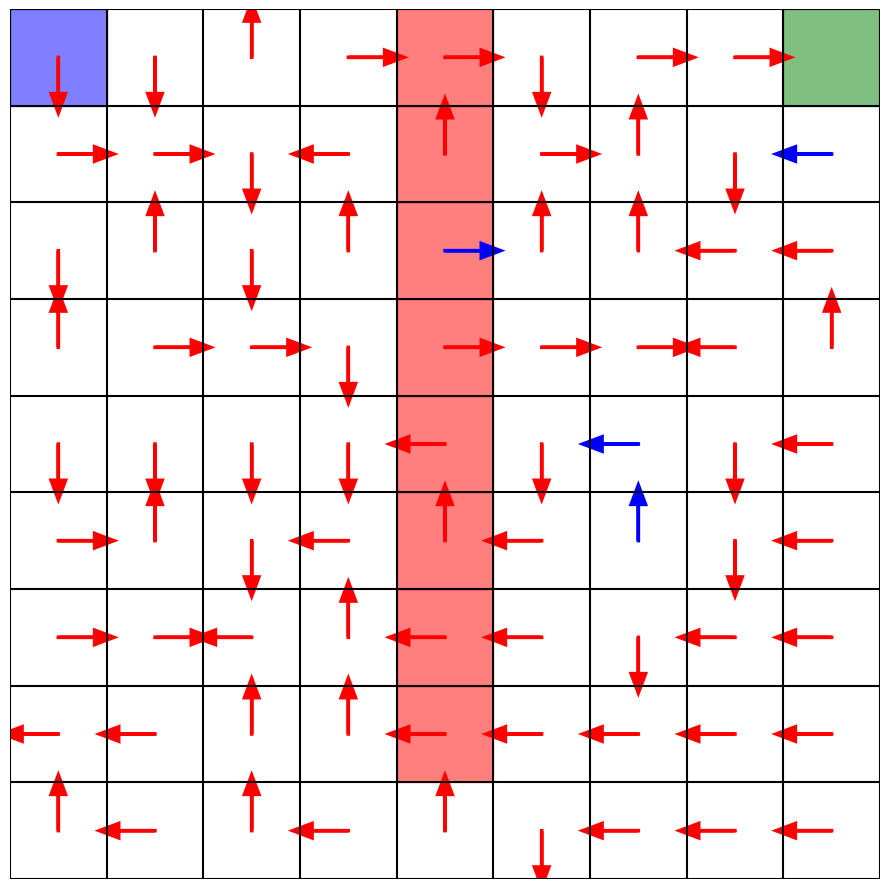

In [23]:
env_random = 0.1
seed = 24
eps = 0.1
q_lr = 1.0
r_lr = 0.1
log_dir = "../models/9_9/Penalty/reward_model/penalty_1/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
q_table = np.load(log_dir + "/critic_q_table_{}.npy".format(seed))
states, actions = get_policy_states_actions("TreasureHunt-Penalty-v1", "reward_model", q_table, grid_size=(9,9))
fig = plot_env_actions("Penalty", states, actions, grid_size=(9,9), legend=False)
fig.savefig(log_dir + "/final_policy_performance_{}.pdf".format(seed), dpi=300)

In [ ]:
np.round(np.load(log_dir + "/reward_model_table_{}.npy".format(seed)), 2)

# No random actions

In [81]:
for env_random in [0.0]:
    for eps in [0.4]:
        for q_lr in [1.0, 0.5, 0.1]:
            for r_lr in [1.0, 0.5, 0.1]:
                log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
                count = 0
                for seed in range(30):
                    r_table = np.load(log_dir + "/reward_model_table_{}.npy".format(seed))
                    if np.max(r_table) >0:
                        count += 1
                        # print(np.where(np.load(log_dir + "/reward_model_table_{}.npy".format(seed)) > 0))
                        # print(seed)
                if count > 0:
                    print("\nenv_random = {}, eps = {}, q_lr= {}, r_lr = {} \t # seeds= {} / 30".format(env_random, eps, q_lr, r_lr, count))


env_random = 0.0, eps = 0.4, q_lr= 1.0, r_lr = 1.0 	 # seeds= 23 / 30

env_random = 0.0, eps = 0.4, q_lr= 1.0, r_lr = 0.5 	 # seeds= 21 / 30

env_random = 0.0, eps = 0.4, q_lr= 1.0, r_lr = 0.1 	 # seeds= 19 / 30


In [8]:
env_random = 0.0
seed = 3
eps = 0.4
q_lr = 1.0
r_lr = 0.5
log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
q_table = np.load(log_dir + "/critic_q_table_{}.npy".format(seed))
states, actions = get_policy_states_actions("TreasureHunt-Penalty-v1", "reward_model", q_table, grid_size=(9,9))
fig = plot_env_actions("Penalty", states, actions, grid_size=(9,9), legend=False)
# fig.savefig(log_dir + "/final_policy_performance_{}.pdf".format(seed), dpi=300)

FileNotFoundError: [Errno 2] No such file or directory: '../models/9_9/Penalty/reward_model/env_0.0/eps_0.4/q_lr_1.0/reward_lr_0.5/critic_q_table_3.npy'

## Zero init, with env random actions

In [9]:
for env_random in [0.1]:
    for eps in [0.3]:
        for q_lr in [1.0, 0.5]:
            for r_lr in [1.0, 0.5, 0.1]:
                log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
                count = 0
                for seed in range(30):
                    r_table = np.load(log_dir + "/reward_model_table_{}.npy".format(seed))
                    if np.max(r_table) > 0:
                        count += 1
                if count > 0:
                    print("\nenv_random = {}, eps = {}, q_lr= {}, r_lr = {} \t # seeds= {} / 30".format(env_random, eps, q_lr, r_lr, count))

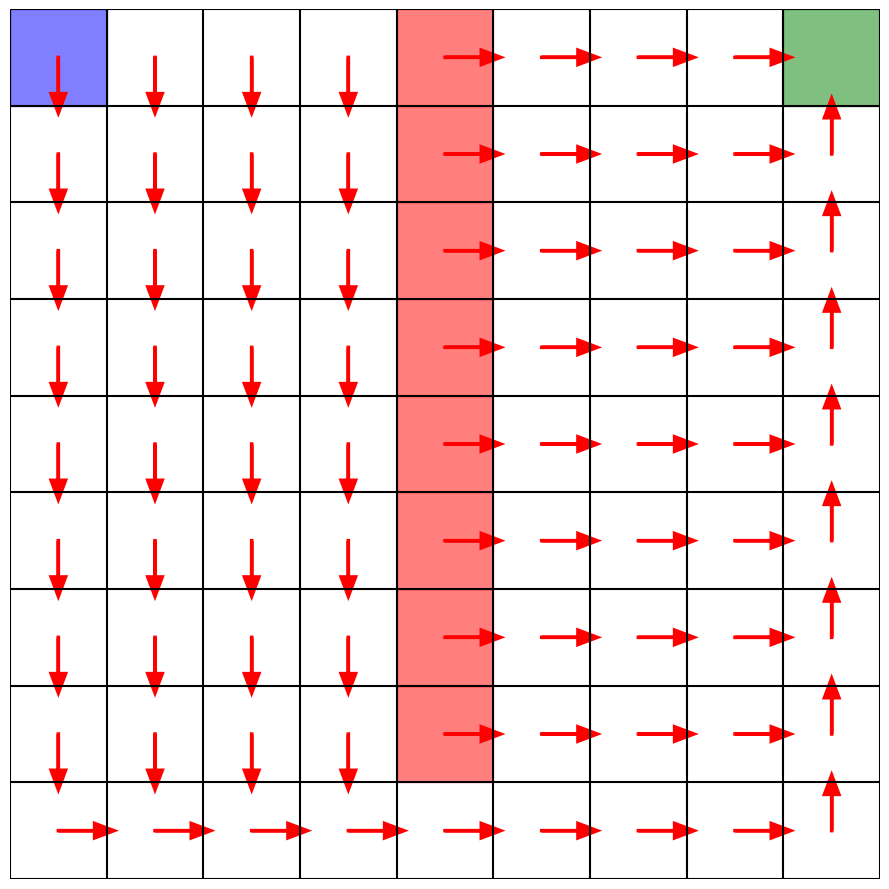

In [121]:
env_random = 0.0
seed = 0
eps = "dec"
q_lr = 1.0
r_lr = 1.0
log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
q_table = np.load(log_dir + "/critic_q_table_{}.npy".format(seed))
states, actions = get_policy_states_actions("TreasureHunt-Penalty-v1", "reward_model", q_table, grid_size=(9,9))
fig = plot_env_actions("Penalty", states, actions, grid_size=(9,9), legend=False)
# fig.savefig(log_dir + "/final_policy_performance_{}.pdf".format(seed), dpi=300)

## Zero init, **without** env random actions, **Decay $\epsilon$**

In [13]:
for env_random in [0.0]:
    for eps in [1.0]:
        for q_lr in [1.0, 0.5, 0.1]:
            for r_lr in [1.0, 0.5, 0.1]:
                log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
                count = 0
                for seed in range(30):
                    r_table = np.load(log_dir + "/reward_model_table_{}.npy".format(seed))
                    if np.max(r_table) > 0:
                        count += 1
                        # print(np.where(np.load(log_dir + "/reward_model_table_{}.npy".format(seed)) > 0))
                        # print(seed)
                if count > 0:
                    print("\nenv_random = {}, eps = {}, q_lr= {}, r_lr = {} \t # seeds= {} / 30".format(env_random, eps, q_lr, r_lr, count))


env_random = 0.0, eps = 1.0, q_lr= 1.0, r_lr = 1.0 	 # seeds= 30 / 30

env_random = 0.0, eps = 1.0, q_lr= 1.0, r_lr = 0.5 	 # seeds= 30 / 30

env_random = 0.0, eps = 1.0, q_lr= 1.0, r_lr = 0.1 	 # seeds= 30 / 30

env_random = 0.0, eps = 1.0, q_lr= 0.5, r_lr = 1.0 	 # seeds= 30 / 30

env_random = 0.0, eps = 1.0, q_lr= 0.5, r_lr = 0.5 	 # seeds= 30 / 30

env_random = 0.0, eps = 1.0, q_lr= 0.5, r_lr = 0.1 	 # seeds= 30 / 30

env_random = 0.0, eps = 1.0, q_lr= 0.1, r_lr = 1.0 	 # seeds= 30 / 30

env_random = 0.0, eps = 1.0, q_lr= 0.1, r_lr = 0.5 	 # seeds= 30 / 30

env_random = 0.0, eps = 1.0, q_lr= 0.1, r_lr = 0.1 	 # seeds= 30 / 30


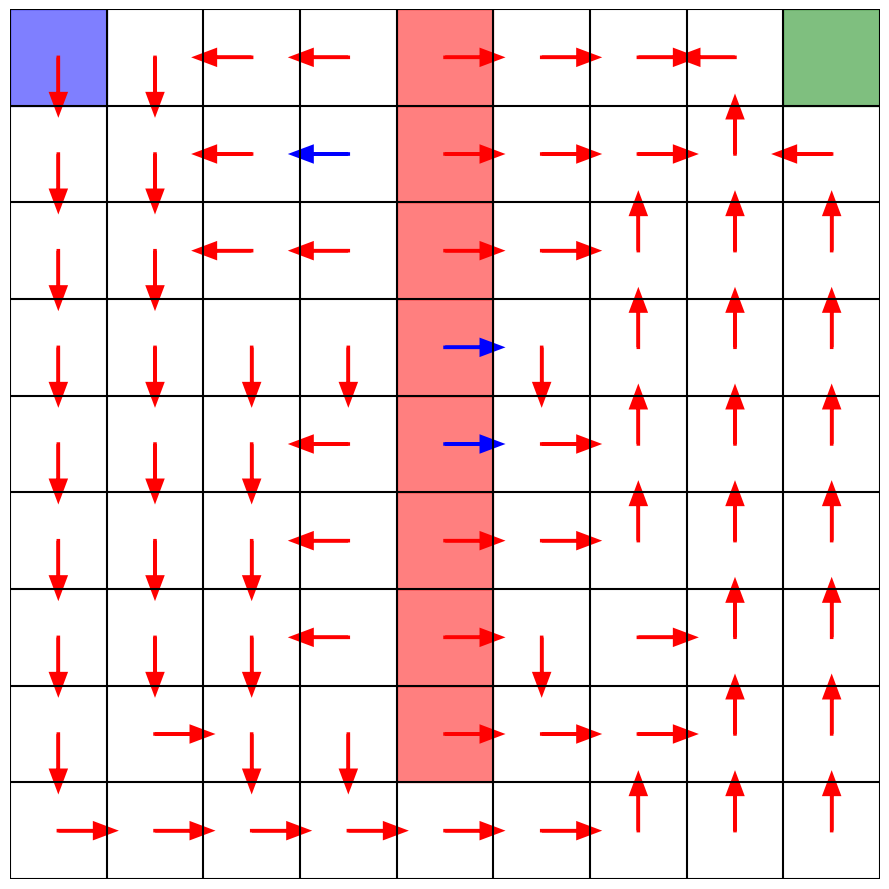

In [30]:
env_random = 0.2
seed = 2
eps = 1.0
q_lr = 0.1
r_lr = 0.1
log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
q_table = np.load(log_dir + "/critic_q_table_{}.npy".format(seed))
states, actions = get_policy_states_actions("TreasureHunt-Penalty-v1", "reward_model", q_table, grid_size=(9,9))
fig = plot_env_actions("Penalty", states, actions, grid_size=(9,9), legend=False)
# fig.savefig(log_dir + "/final_policy_performance_{}.pdf".format(seed), dpi=300)

In [24]:
env_random = 0.0
seed = 1
eps = 0.4
q_lr = 1.0
r_lr = 0.5
log_dir = "../models/9_9/Penalty/reward_model/env_{}/eps_{}/q_lr_{}/reward_lr_{}".format(env_random, eps, q_lr, r_lr)
np.where(np.load(log_dir + "/reward_model_table_{}.npy".format(seed)) < -1)[0]

array([ 3, 12, 13, 13, 21, 22, 30, 31, 39, 48, 49, 57, 58, 58, 66, 76])

In [31]:
np.sort(np.concatenate((np.arange(3, 81, 9), np.arange(4, 72, 9), np.arange(5, 72, 9)))).shape

(25,)

In [32]:
16+8+7

31